# Pose Estimation Algorithm
### Imports

In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import trimesh
from mclasses.Pose import Pose
from mclasses.PoseObject import PoseObject
from mclasses.FilenamesHelper import FilenamesHelper

# Set up matplotlib for inline viewing
%matplotlib inline

### Load Camera Calibrations

In [2]:
def load_camera_intrinsics():
    """Loads the RGB camera matrix from the calibrations file."""
    # Use your new helper to get the path
    calib_path = FilenamesHelper.get_camera_calibrations_file_path()

    fs = cv2.FileStorage(calib_path, cv2.FILE_STORAGE_READ)

    # Read the correct node
    camera_matrix = fs.getNode("rgb_calibration").mat()
    fs.release()

    # Assume zero distortion if not provided in the calibration file
    dist_coeffs = np.zeros((4, 1), dtype=np.float32)

    return camera_matrix, dist_coeffs

In [3]:
# Load intrinsics
K, dist_coeffs = load_camera_intrinsics()
print("Camera Matrix:\n", K)
print("Distortion Coefficients:\n", dist_coeffs)

Camera Matrix:
 [[575.81573   0.      319.5    ]
 [  0.      575.81573 239.5    ]
 [  0.        0.        1.     ]]
Distortion Coefficients:
 [[0.]
 [0.]
 [0.]
 [0.]]


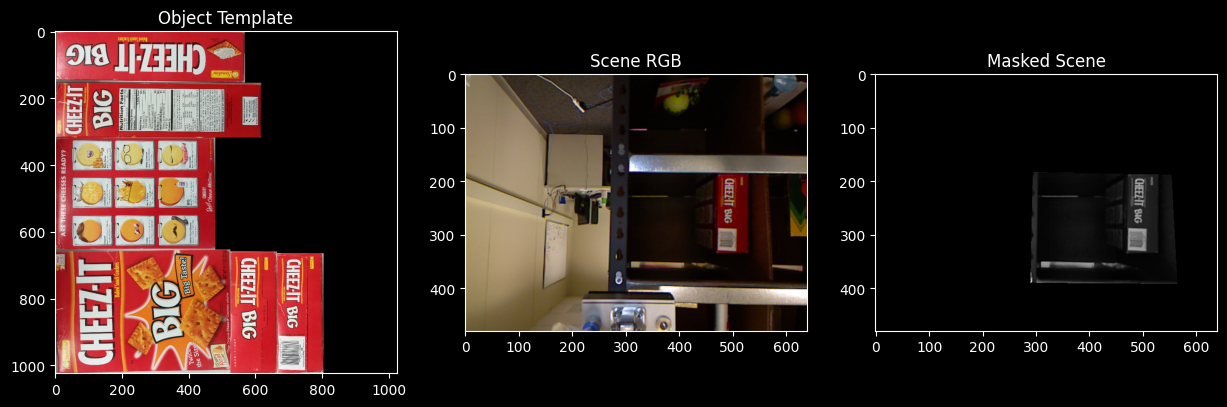

In [4]:
# The base filename (without path)
target_filename = "cheezit_big_original-image-F-1-1-0.png"

# Initialize our object. Note: PoseObject's __init__ will automatically use
# FilenamesHelper to find and load the ground truth pose!
obj_data = PoseObject(target_filename)

# Load the images using the new FilenamesHelper paths
rgb_img = cv2.imread(FilenamesHelper.get_image_file_path(obj_data, run_number=1))
depth_img = cv2.imread(FilenamesHelper.get_depth_file_path(obj_data, run_number=1), cv2.IMREAD_UNCHANGED)
mask_img = cv2.imread(FilenamesHelper.get_mask_file_path(obj_data, run_number=1), cv2.IMREAD_GRAYSCALE)

# Load the texture using the new FilenamesHelper
template_img = cv2.imread(FilenamesHelper.get_texture_file_path(obj_data))

# Convert RGB to Grayscale for feature matching
scene_gray = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)

# Apply the bin mask to the scene to ignore background clutter outside the bin
masked_scene = cv2.bitwise_and(scene_gray, scene_gray, mask=mask_img)

# Quick visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv2.cvtColor(template_img, cv2.COLOR_BGR2RGB)); ax[0].set_title("Object Template")
ax[1].imshow(cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)); ax[1].set_title("Scene RGB")
ax[2].imshow(masked_scene, cmap='gray'); ax[2].set_title("Masked Scene")
plt.show()

In [6]:
def find_feature_matches(templ_gray, scn_gray, num_matches=100):
    """Detects SIFT features and finds the best matches."""
    # 1. Initialize SIFT detector
    sift = cv2.SIFT_create()

    # 2. Find keypoints and descriptors
    kp_temp, des_temp = sift.detectAndCompute(templ_gray, None)
    kp_scene, des_scene = sift.detectAndCompute(scn_gray, None)

    # 3. Match features using Brute Force Matcher (Note: NORM_L2 for SIFT)
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des_temp, des_scene)

    # Sort matches by distance (lower distance = better match)
    matches = sorted(matches, key=lambda x: x.distance)
    good_matches = matches[:num_matches]

    return kp_temp, kp_scene, good_matches

In [7]:
def draw_feature_matches(template_img, kp_temp, scene_img, kp_scene, matches):
    """Draws lines connecting the matched keypoints between the two images."""
    # OpenCV has a built-in function specifically for visualizing this!
    matched_vis = cv2.drawMatches(
        template_img, kp_temp,
        scene_img, kp_scene,
        matches, None,
        matchColor=(0, 255, 0), # Green lines for matches
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Display using matplotlib
    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(matched_vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Top {len(matches)} ORB Feature Matches")
    plt.axis('off')
    plt.show()

In [8]:
# Find the matches between the template and the masked scene
kp_temp, kp_scene, good_matches = find_feature_matches(template_gray, masked_scene, num_matches=100)

print(f"Found {len(good_matches)} high-quality matches!")

Found 100 high-quality matches!


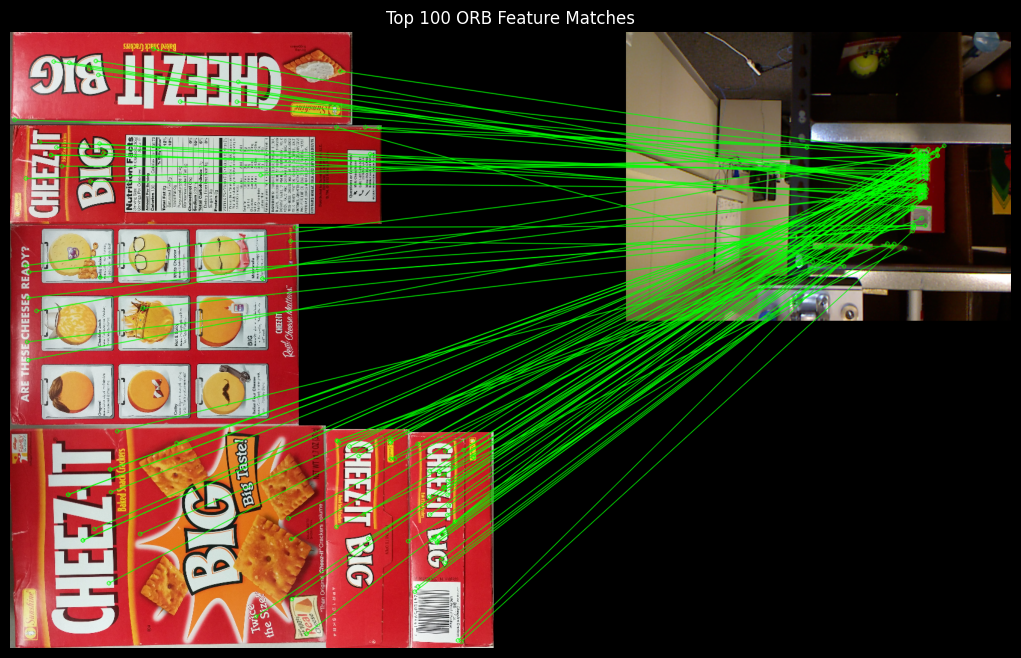

In [9]:
# Draw the matches! We pass the color images here so the visualization looks nicer.
draw_feature_matches(template_img, kp_temp, rgb_img, kp_scene, good_matches)

In [10]:
def generate_scene_point_cloud(rgb_img, depth_img, mask_img, K):
    """Converts a 2D depth map into a 3D point cloud using camera intrinsics."""
    # Apply mask so we only reconstruct the bin/object area
    masked_depth = cv2.bitwise_and(depth_img, depth_img, mask=mask_img)

    # The Rutgers Kinect dataset depth values are typically in millimeters.
    # We divide by 1000.0 to convert the depth values into METERS.
    depth_meters = masked_depth.astype(np.float32) / 1000.0

    # Extract camera matrix parameters
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]

    h, w = depth_meters.shape
    u, v = np.meshgrid(np.arange(w), np.arange(h))

    # Filter out pixels where depth is 0 (invalid data)
    valid = depth_meters > 0

    # Apply the pinhole camera equations
    z = depth_meters[valid]
    x = (u[valid] - cx) * z / fx
    y = (v[valid] - cy) * z / fy

    # Stack the arrays into a list of 3D coordinates (N, 3)
    points_3d = np.vstack((x, y, z)).T

    # Extract the corresponding RGB colors for visualization
    colors = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)[valid]

    # Create the trimesh PointCloud object
    scene_pc = trimesh.points.PointCloud(points_3d, colors=colors)
    return scene_pc, points_3d, depth_meters

In [12]:
scene_pc, scene_points_3d, depth_meters = generate_scene_point_cloud(rgb_img, depth_img, mask_img, K)
print(f"Generated Scene Point Cloud with {len(scene_points_3d)} 3D points.")
# Uncomment the line below to open an interactive 3D viewer!
# scene_pc.show()

Generated Scene Point Cloud with 32904 3D points.


In [13]:
def generate_model_point_cloud(obj_path, num_points=15000):
    """Loads a 3D CAD model and samples a point cloud from its surface."""
    # Load the mesh (make sure the .mtl file is in the same directory)
    mesh = trimesh.load(obj_path)

    # Sample 3D points across the faces of the mesh
    points_3d, face_indices = trimesh.sample.sample_surface(mesh, num_points)

    model_pc = trimesh.points.PointCloud(points_3d)
    return model_pc, mesh

In [14]:
# Ensure you have your obj_data configured from our previous FilenamesHelper
obj_file_path = FilenamesHelper.get_obj_file_path(obj_data)
model_pc, cad_mesh = generate_model_point_cloud(obj_file_path)

print(f"Generated Model Point Cloud with {len(model_pc.vertices)} 3D points.")
# Uncomment the line below to see your 3D CAD model point cloud!
# model_pc.show()

Generated Model Point Cloud with 15000 3D points.


In [16]:
def estimate_pose_from_matches_3d(kp_temp, kp_scene, matches, K, dist_coeffs, template_shape, cad_mesh):
    """
    Uses matched keypoints to estimate a coarse 6-DOF pose using PnP,
    scaling the 2D template into 3D metric coordinates using the CAD model.
    """
    if len(matches) < 4:
        print("Error: Not enough matches to compute pose.")
        return None, None

    # 1. Get the physical dimensions of the 3D model (in meters)
    # cad_mesh.extents returns [width_X, height_Y, depth_Z]
    physical_width = cad_mesh.extents[0]
    physical_height = cad_mesh.extents[1]

    # 2. Get the pixel dimensions of our 2D template image
    h_pix, w_pix = template_shape[:2]

    # 3. Calculate the conversion factor from pixels to meters
    scale_x = physical_width / w_pix
    scale_y = physical_height / h_pix

    # 4. Extract and convert matches to 3D metric coordinates
    obj_points_3d = []
    pts_scene = []

    for m in matches:
        # Get 2D pixel coordinates on the template
        u_temp, v_temp = kp_temp[m.queryIdx].pt

        # Convert to 3D metric coordinates AND center them around (0,0)
        # Centering is crucial because the 3D CAD model's origin (0,0,0) is usually its center!
        x_metric = (u_temp - w_pix / 2.0) * scale_x
        y_metric = (v_temp - h_pix / 2.0) * scale_y
        z_metric = 0.0 # Assuming the matched texture lies on the front flat face (Z=0)

        obj_points_3d.append([x_metric, y_metric, z_metric])

        # Get 2D pixel coordinates in the scene
        pts_scene.append(kp_scene[m.trainIdx].pt)

    obj_points_3d = np.float32(obj_points_3d)
    pts_scene = np.float32(pts_scene)

    # 5. Solve PnP to find the Coarse Initial Pose
    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        obj_points_3d, pts_scene, K, dist_coeffs,
        reprojectionError=5.0, iterationsCount=100
    )

    if success:
        # Convert the rotation vector into a 3x3 rotation matrix
        R_est, _ = cv2.Rodrigues(rvec)
        return R_est, tvec
    else:
        print("Pose estimation failed to find enough inliers.")
        return None, None

In [15]:
def calculate_pose_error(R_est, t_est, gt_pose: Pose):
    """Calculates L2 Translational Error (meters) and Angular Rotational Error (degrees)."""
    # 1. Translational Error (L2 Euclidean Distance)
    # Ensure t_est is a 3x1 vector to match gt_pose.translation
    t_est = np.array(t_est).reshape(3, 1)
    gt_t = np.array(gt_pose.translation).reshape(3, 1)

    trans_error_meters = np.linalg.norm(t_est - gt_t)

    # 2. Rotational Error (Angle distance)
    R_gt = gt_pose.rotation
    R_diff = np.dot(R_est, R_gt.T)
    trace = np.trace(R_diff)

    # Clip trace to [-1, 3] to avoid math domain errors due to floating point precision
    trace = np.clip(trace, -1.0, 3.0)
    rot_error_rad = math.acos((trace - 1.0) / 2.0)
    rot_error_deg = math.degrees(rot_error_rad)

    return trans_error_meters, rot_error_deg

In [17]:
# --- Execution Step ---
# Call the updated function using our SIFT matches and the CAD mesh
R_est, t_est = estimate_pose_from_matches_3d(
    kp_temp,
    kp_scene,
    good_matches,
    K,
    dist_coeffs,
    template_gray.shape,
    cad_mesh
)

if R_est is not None:
    print("Coarse Estimated Translation Vector (in meters!):\n", t_est)
    t_err_coarse, r_err_coarse = calculate_pose_error(R_est, t_est, obj_data.pose)
    print(f"\n--- Coarse Accuracy Report ---")
    print(f"Translational Error: {t_err_coarse:.4f} meters")
    print(f"Rotational Error: {r_err_coarse:.4f} degrees")

Coarse Estimated Translation Vector (in meters!):
 [[1.16417555e+14]
 [1.13246365e+13]
 [3.94744642e+14]]

--- Coarse Accuracy Report ---
Translational Error: 411709396119571.9375 meters
Rotational Error: 159.3859 degrees


In [18]:
def refine_pose_icp(model_pc, scene_pc, R_initial, t_initial):
    """
    Refines a coarse pose estimate using the Iterative Closest Point (ICP) algorithm.
    """
    # 1. Extract raw numpy arrays from the trimesh PointCloud objects
    model_points = np.array(model_pc.vertices)
    scene_points = np.array(scene_pc.vertices)

    # 2. Build the 4x4 initial transformation matrix from our PnP results
    initial_transform = np.eye(4)
    if R_initial is not None and t_initial is not None:
        initial_transform[0:3, 0:3] = R_initial
        initial_transform[0:3, 3:4] = t_initial.reshape(3, 1)

    print("Running ICP Registration... (This may take a few seconds)")

    # 3. Run trimesh's ICP
    # a = points to move (model), b = target points (scene)
    icp_matrix, transformed_points, cost = trimesh.registration.icp(
        model_points,
        scene_points,
        initial=initial_transform,
        threshold=1e-5,
        max_iterations=50
    )

    # 4. Extract the refined Rotation and Translation
    R_refined = icp_matrix[0:3, 0:3]
    t_refined = icp_matrix[0:3, 3:4]

    # 5. Create a new point cloud of the perfectly aligned model for visualization
    aligned_model_pc = trimesh.points.PointCloud(transformed_points)
    # Give it a bright red color so it stands out against the scene
    aligned_model_pc.colors = [255, 0, 0, 255]

    return R_refined, t_refined, aligned_model_pc, cost

In [19]:
# Let's run it! (Assuming R_est and t_est are available from Cell 7)
R_final, t_final, aligned_model, icp_cost = refine_pose_icp(model_pc, scene_pc, R_est, t_est)

print(f"ICP completed with alignment cost: {icp_cost:.6f}")

Running ICP Registration... (This may take a few seconds)
ICP completed with alignment cost: 0.000000


In [21]:
print("Final Rotation", R_final)
print("Final Translation", t_final)

Final Rotation [[ 1.65360835e-12  1.42496202e-12 -4.30455314e-13]
 [ 1.37911544e-12 -1.70871655e-12 -3.58549137e-13]
 [ 5.60222409e-13  3.36069163e-16  2.15322545e-12]]
Final Translation [[0.21185423]
 [0.18077137]
 [0.94199997]]


In [22]:
# Calculate the newly refined error
t_err_final, r_err_final = calculate_pose_error(R_final, t_final, obj_data.pose)

print("\n=== FINAL PIPELINE ACCURACY ===")
print(f"Translational Error: {t_err_final:.4f} meters")
print(f"Rotational Error: {r_err_final:.4f} degrees")

# Visualize the final alignment in an interactive 3D window
# The scene will display its original colors, and the CAD model will overlay in RED
# visual_scene = trimesh.Scene([scene_pc, aligned_model])

# print("\nOpening 3D Interactive Viewer... (Close the viewer window to continue)")
# visual_scene.show() # Uncomment this when running locally to pop open the 3D window!


=== FINAL PIPELINE ACCURACY ===
Translational Error: 0.2874 meters
Rotational Error: 120.0000 degrees
